# 卡尔曼滤波处理 (Kalman Filtering)

**目的**: 对整合后的CGM数据进行卡尔曼滤波，以减少传感器噪声和测量误差，提取更真实的血糖变化趋势，为后续预测模型提供高质量输入。

**方法**:
1.  读取 `merged_cgm_data.csv`。
2.  实现卡尔曼滤波器 (Kalman Filter)，采用恒定速度模型 (Constant Velocity Model)。
3.  对每个受试者的数据进行滤波处理。
4.  可视化对比滤波前后的效果。
5.  导出处理后的数据。

In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 设置科研绘图风格
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100

print("Libraries imported and style set.")

Libraries imported and style set.


In [2]:
# 读取数据
input_path = '../../DataFormat/merged_cgm_data.csv'
print(f"Reading data from: {input_path}")

if os.path.exists(input_path):
    df = pd.read_csv(input_path)
    df['time'] = pd.to_datetime(df['time'])
    print(f"Data loaded successfully. Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Unique subjects: {df['id'].nunique()}")
else:
    print(f"Error: File not found at {input_path}")

Reading data from: ../../DataFormat/merged_cgm_data.csv
Data loaded successfully. Shape: (101600, 5)
Columns: ['id', 'time', 'gl', 'age', 'bmi']
Unique subjects: 168


In [3]:
# 定义卡尔曼滤波器类
class KalmanFilter:
    def __init__(self, process_noise=1e-5, measurement_noise=1e-1, dt=1.0):
        """
        初始化卡尔曼滤波器 (Constant Velocity Model)
        State vector x = [glucose, velocity]^T
        """
        self.dt = dt
        
        # 状态转移矩阵 F
        # x_k = x_{k-1} + v_{k-1} * dt
        # v_k = v_{k-1}
        self.F = np.array([[1, dt],
                           [0, 1]])
        
        # 观测矩阵 H
        # z_k = glucose_k
        self.H = np.array([[1, 0]])
        
        # 过程噪声协方差矩阵 Q
        # 假设加速度是过程噪声来源
        self.Q = np.array([[dt**4/4, dt**3/2],
                           [dt**3/2, dt**2]]) * process_noise
        
        # 观测噪声协方差矩阵 R
        self.R = np.array([[measurement_noise]])
        
        # 初始状态协方差矩阵 P
        self.P = np.eye(2) * 1.0
        
        # 初始状态 x
        self.x = np.zeros((2, 1))

    def initialize(self, initial_value):
        """初始化状态"""
        self.x = np.array([[initial_value], [0]])
        self.P = np.eye(2) * 1.0

    def predict(self):
        """预测步骤"""
        self.x = np.dot(self.F, self.x)
        self.P = np.dot(np.dot(self.F, self.P), self.F.T) + self.Q
        return self.x[0, 0]

    def update(self, measurement):
        """更新步骤"""
        z = np.array([[measurement]])
        y = z - np.dot(self.H, self.x)  # Innovation
        S = np.dot(np.dot(self.H, self.P), self.H.T) + self.R  # Innovation covariance
        K = np.dot(np.dot(self.P, self.H.T), np.linalg.inv(S))  # Kalman gain
        
        self.x = self.x + np.dot(K, y)
        I = np.eye(self.F.shape[0])
        self.P = np.dot(I - np.dot(K, self.H), self.P)
        
        return self.x[0, 0]

    def smooth(self, data):
        """对整个序列进行滤波"""
        results = []
        if len(data) == 0:
            return results
            
        # 初始化
        self.initialize(data[0])
        results.append(data[0])
        
        # 迭代处理
        for z in data[1:]:
            self.predict()
            filtered_val = self.update(z)
            results.append(filtered_val)
            
        return np.array(results)

print("KalmanFilter class defined.")

KalmanFilter class defined.


In [4]:
# 应用卡尔曼滤波
print("Applying Kalman Filter to all subjects...")

# 参数设置
# Q (Process Noise): 较小的值表示我们相信模型预测（平滑），较大的值表示我们相信系统变化快
# R (Measurement Noise): 较大的值表示我们认为测量噪声大（平滑），较小的值表示我们相信测量值
PROCESS_NOISE = 0.5
MEASUREMENT_NOISE = 10.0  # 假设传感器误差方差约为 10 (mg/dL)^2

filtered_dfs = []
unique_subjects = sorted(df['id'].unique())

for subject_id in unique_subjects:
    # 获取该受试者数据
    subject_data = df[df['id'] == subject_id].sort_values('time').copy()
    
    # 处理缺失值：移除 gl 为 NaN 的行 (Kalman滤波器对初始值敏感，不能为NaN)
    original_len = len(subject_data)
    subject_data = subject_data.dropna(subset=['gl'])
    
    if subject_data.empty:
        continue
    
    # 初始化滤波器
    kf = KalmanFilter(process_noise=PROCESS_NOISE, 
                      measurement_noise=MEASUREMENT_NOISE, 
                      dt=1.0) # dt=1 step (5 mins)
    
    # 执行滤波
    gl_values = subject_data['gl'].values
    filtered_values = kf.smooth(gl_values)
    
    # 保存结果
    subject_data['gl_kalman'] = filtered_values
    
    # 计算残差 (Residuals)
    subject_data['residual'] = subject_data['gl'] - subject_data['gl_kalman']
    
    filtered_dfs.append(subject_data)

# 合并结果
df_filtered = pd.concat(filtered_dfs, ignore_index=True)

print("Filtering complete.")
print(f"Filtered data shape: {df_filtered.shape}")
df_filtered.head()

Applying Kalman Filter to all subjects...
Filtering complete.
Filtered data shape: (101596, 7)


,id,time,gl,age,bmi,gl_kalman,residual
0,2,2012-01-01 00:00:00,167.0,42.0,30.0,167.000000,0.000000
1,2,2012-01-01 00:05:00,163.0,42.0,30.0,166.298969,-3.298969
2,2,2012-01-01 00:10:00,158.0,42.0,30.0,163.151082,-5.151082
3,2,2012-01-01 00:15:00,151.0,42.0,30.0,156.616025,-5.616025
4,2,2012-01-01 00:20:00,144.0,42.0,30.0,148.539769,-4.539769


Generating plots for 10 subjects


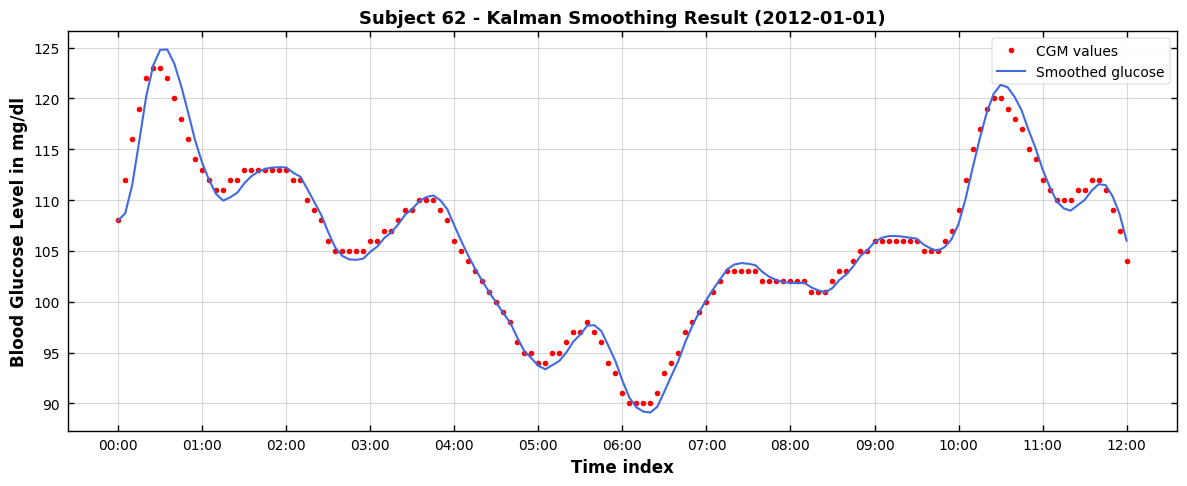

Visualization for Subject 62 generated.


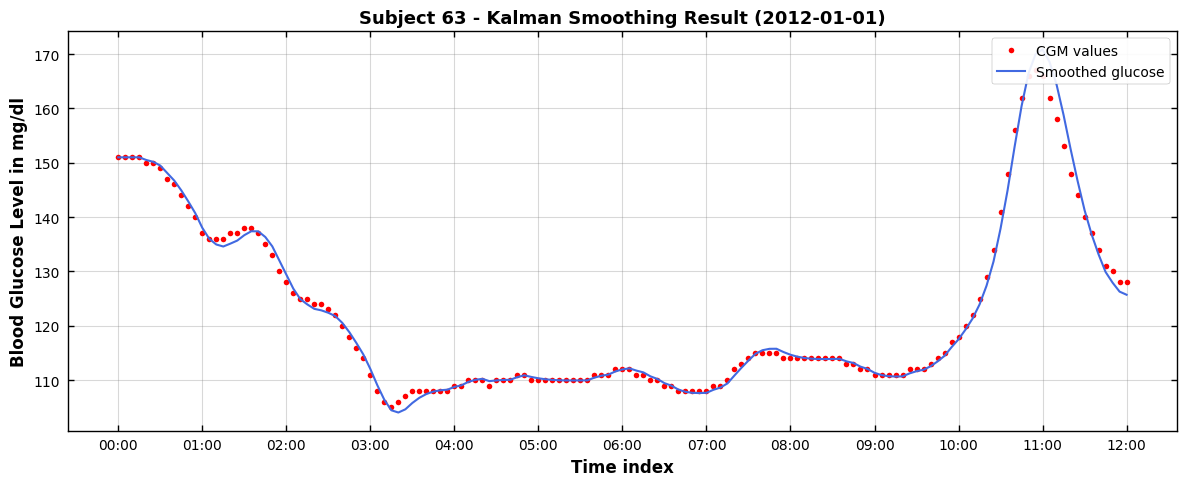

Visualization for Subject 63 generated.


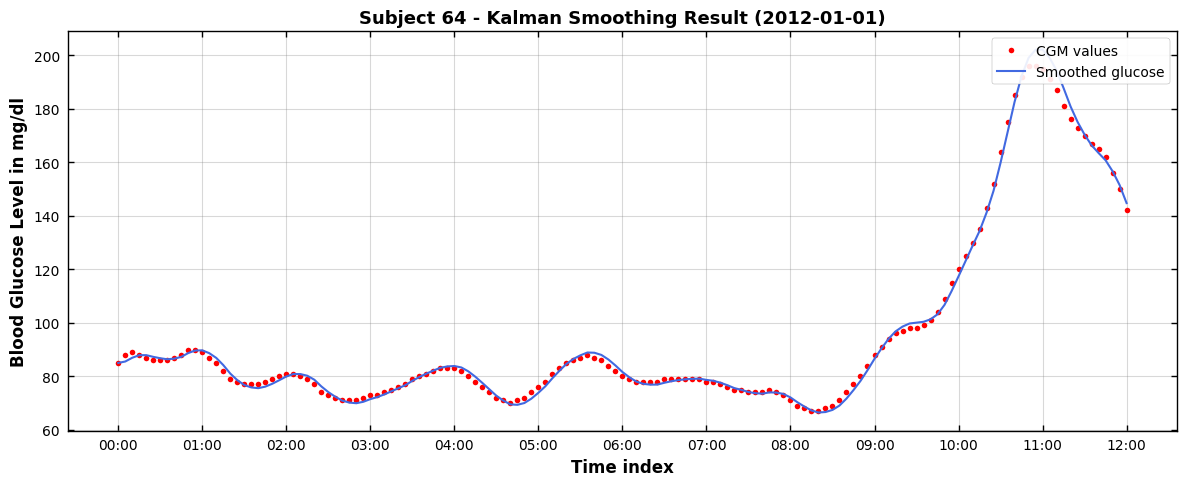

Visualization for Subject 64 generated.


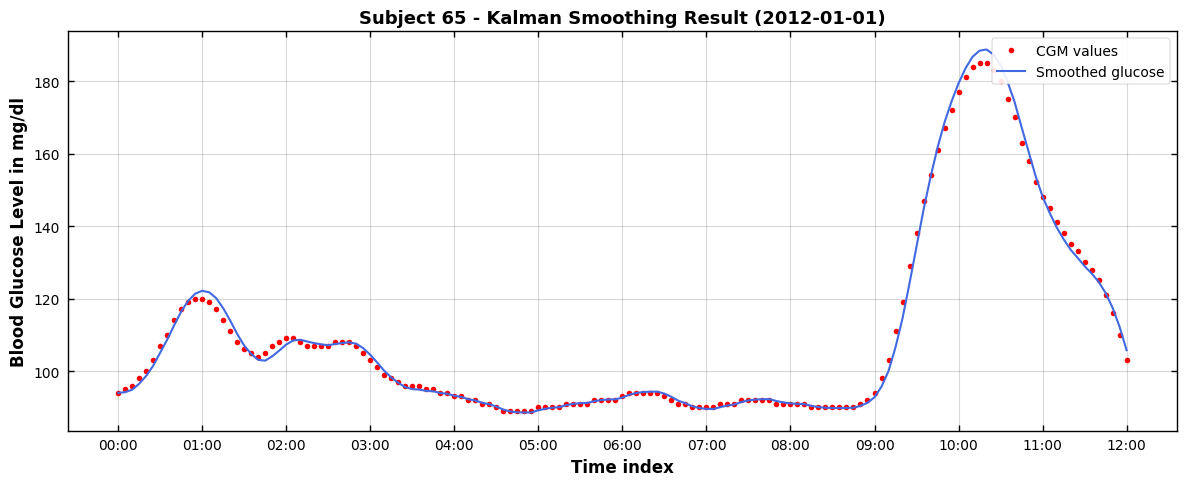

Visualization for Subject 65 generated.


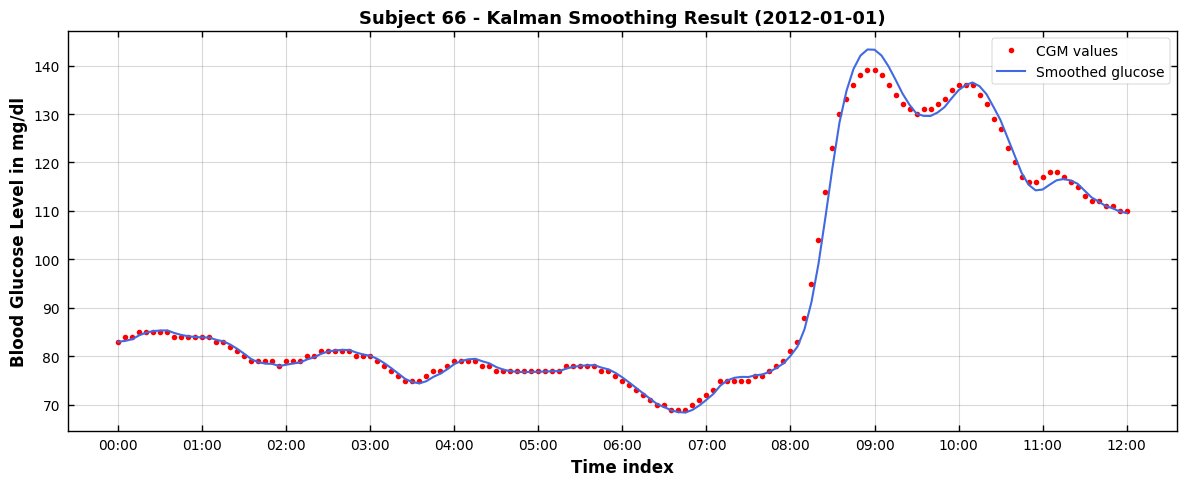

Visualization for Subject 66 generated.


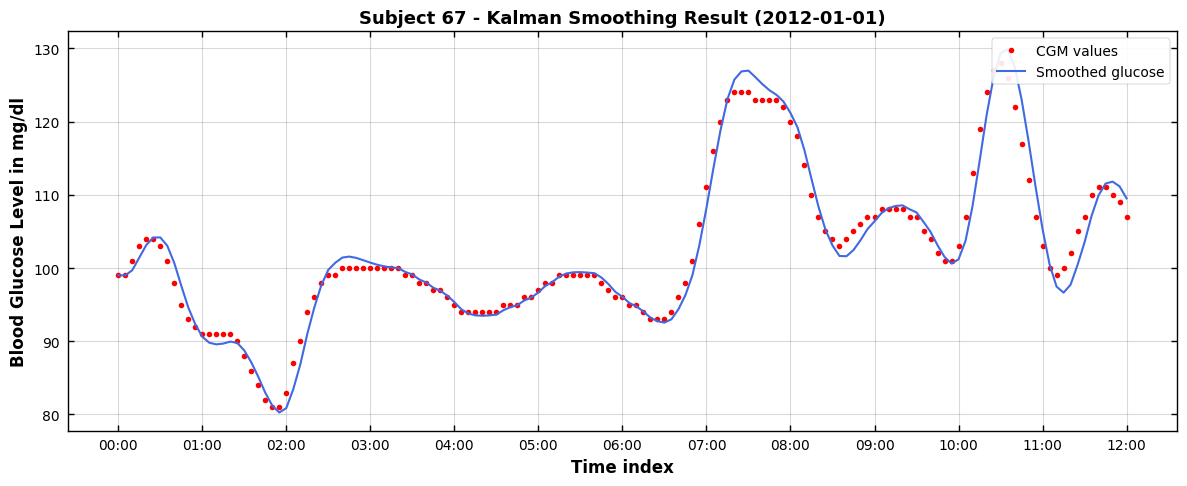

Visualization for Subject 67 generated.


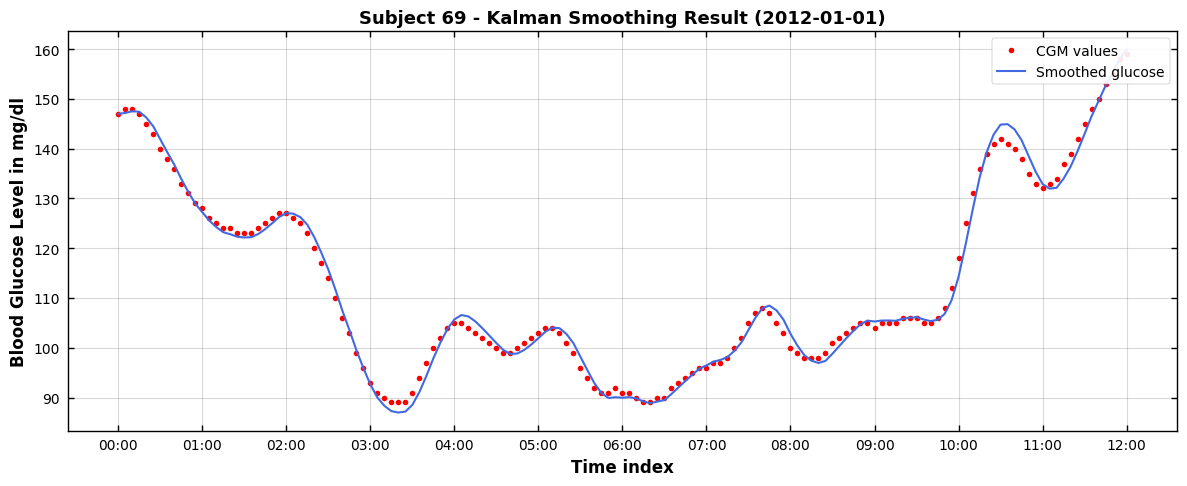

Visualization for Subject 69 generated.


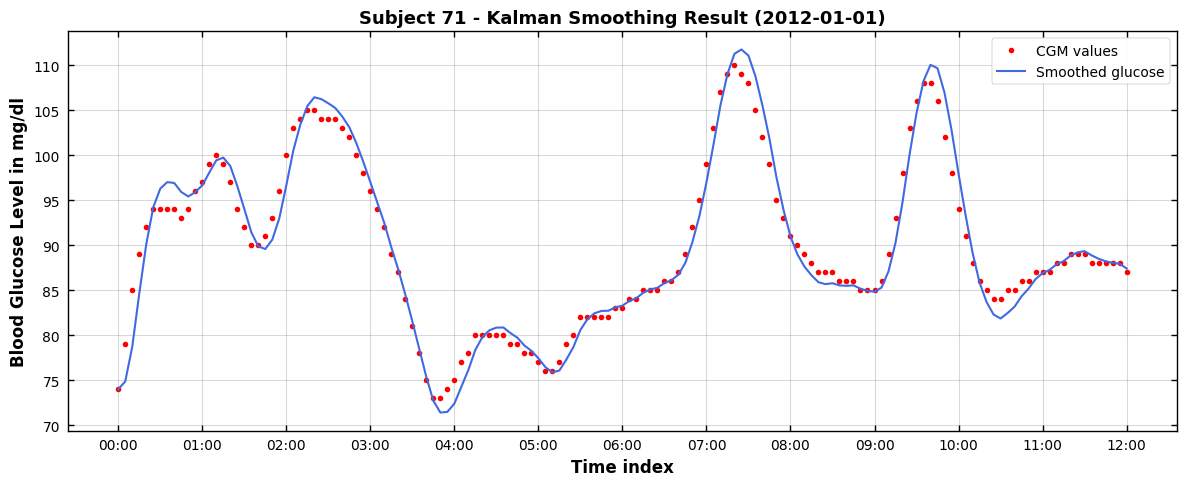

Visualization for Subject 71 generated.


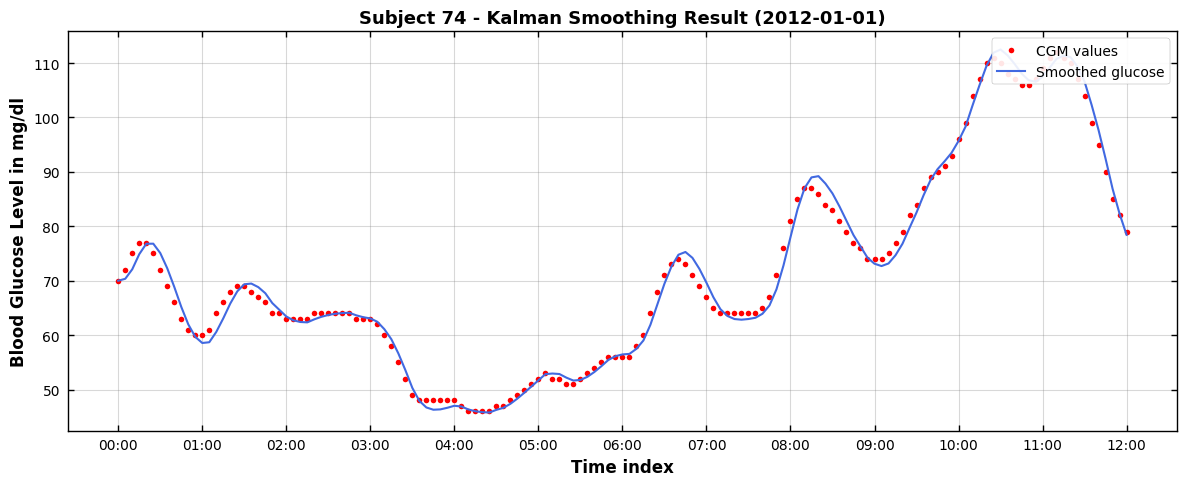

Visualization for Subject 74 generated.


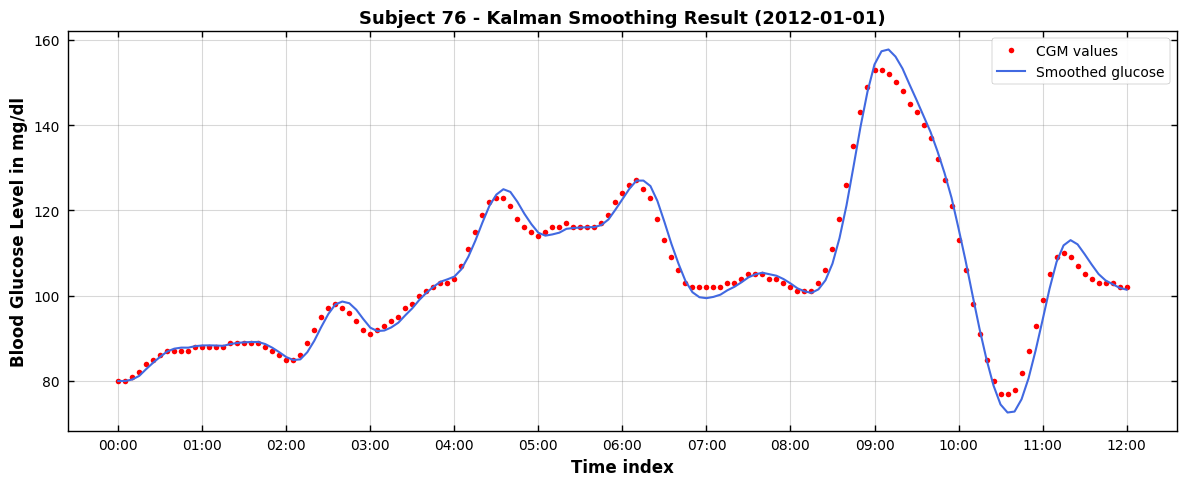

Visualization for Subject 76 generated.


In [5]:
# 可视化对比 (仿照参考图风格)
# 选择前3个受试者进行展示
subjects_to_plot = unique_subjects[50:60]

print(f"Generating plots for {len(subjects_to_plot)} subjects")

for i, subject_id in enumerate(subjects_to_plot):
    subject_data = df_filtered[df_filtered['id'] == subject_id].copy()
    
    # 找到数据点最多的一天
    subject_data['date'] = subject_data['time'].dt.date
    if subject_data.empty:
        continue
        
    best_date = subject_data['date'].value_counts().idxmax()
    full_day_data = subject_data[subject_data['date'] == best_date].sort_values('time')
    
    # 截取12小时的数据进行展示
    if not full_day_data.empty:
        start_time = full_day_data['time'].iloc[0]
        end_time = start_time + pd.Timedelta(hours=12)
        plot_data = full_day_data[(full_day_data['time'] >= start_time) & (full_day_data['time'] <= end_time)]
    else:
        plot_data = full_day_data

    if plot_data.empty:
        continue
    
    # 创建图表 - 单个图 (仿照论文风格)
    plt.figure(figsize=(12, 5))
    
    # 绘制原始数据 (红点)
    plt.plot(plot_data['time'], plot_data['gl'], '.', color='red', markersize=8, label='CGM values')
    
    # 绘制滤波数据 (蓝线)
    plt.plot(plot_data['time'], plot_data['gl_kalman'], '-', color='royalblue', linewidth=1.5, label='Smoothed glucose')
    
    # 设置标签和标题
    plt.ylabel('Blood Glucose Level in mg/dl', fontweight='bold')
    plt.xlabel('Time index', fontweight='bold')
    plt.title(f'Subject {subject_id} - Kalman Smoothing Result ({best_date})', fontweight='bold')
    
    # 设置图例 (右上角，带边框)
    plt.legend(loc='upper right', frameon=True, framealpha=0.9, edgecolor='gray')
    
    # 设置网格 (向内刻度)
    plt.grid(True, alpha=0.3, linestyle='-', color='gray')
    
    # 格式化时间轴
    import matplotlib.dates as mdates
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')) # 仅显示小时:分钟
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    
    # 设置边框和刻度样式
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color('black')
        
    plt.tick_params(direction='in', length=4, width=1, colors='black', top=True, right=True)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Visualization for Subject {subject_id} generated.")

In [6]:
# 导出滤波后的数据
output_file = 'kalman_filtered_cgm_data.csv'
print(f"Exporting filtered data to: {output_file}")

# 选择要导出的列
export_cols = ['id', 'time', 'gl_kalman', 'age', 'bmi']
df_export = df_filtered[export_cols]

# 导出
df_export.to_csv(output_file, index=False)

print("Export complete.")
print(f"File saved: {os.path.abspath(output_file)}")
df_export.head()

Exporting filtered data to: kalman_filtered_cgm_data.csv
Export complete.
File saved: c:\Users\江一骏\Desktop\学习\HKU\dissertation\engineering\code\GlucosePrediction\src\DataFillter\kalman\kalman_filtered_cgm_data.csv


,id,time,gl_kalman,age,bmi
0,2,2012-01-01 00:00:00,167.000000,42.0,30.0
1,2,2012-01-01 00:05:00,166.298969,42.0,30.0
2,2,2012-01-01 00:10:00,163.151082,42.0,30.0
3,2,2012-01-01 00:15:00,156.616025,42.0,30.0
4,2,2012-01-01 00:20:00,148.539769,42.0,30.0


## 总结

1.  **卡尔曼滤波**: 成功实现了基于恒定速度模型的卡尔曼滤波器。
2.  **数据处理**: 对所有受试者的血糖数据进行了平滑处理，生成了 `gl_kalman` 列。
3.  **可视化**: 展示了滤波效果，可以看到滤波后的曲线更加平滑，去除了高频噪声，同时保留了主要的生理趋势。
4.  **数据导出**: 结果已保存至 `kalman_filtered_cgm_data.csv`，可用于后续的模型训练。